<a href="https://colab.research.google.com/github/chandraPrakash-tripathi/CHURN-DATA-ANALYSIS/blob/master1/Analysis2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Initial Data Understanding & Setup Import Essential Libraries

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, chi2, RFE

# Model building
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Statistical tests
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

Load and Initial Inspection

In [3]:
# Load dataset
df = pd.read_csv('customer_churn_dataset.csv')

# Basic information
print("Dataset Shape:", df.shape)
print("\nColumn Info:")
print(df.info())
print("\nFirst 2 rows for sanity check:")
print(df.head(2))
print("\nTarget distribution:")
print(df['Churn'].value_counts())

Dataset Shape: (10000, 12)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       10000 non-null  object 
 1   gender           9000 non-null   object 
 2   SeniorCitizen    9000 non-null   float64
 3   Partner          9000 non-null   object 
 4   Dependents       9000 non-null   object 
 5   tenure           9000 non-null   float64
 6   PhoneService     9000 non-null   object 
 7   MultipleLines    9000 non-null   object 
 8   InternetService  9000 non-null   object 
 9   OnlineSecurity   9000 non-null   object 
 10  OnlineBackup     9000 non-null   object 
 11  Churn            10000 non-null  int64  
dtypes: float64(2), int64(1), object(9)
memory usage: 937.6+ KB
None

First 2 rows for sanity check:
  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Cust_1    Male       

2. Data Exploration & Visualization Strategy

A. Univariate Analysis

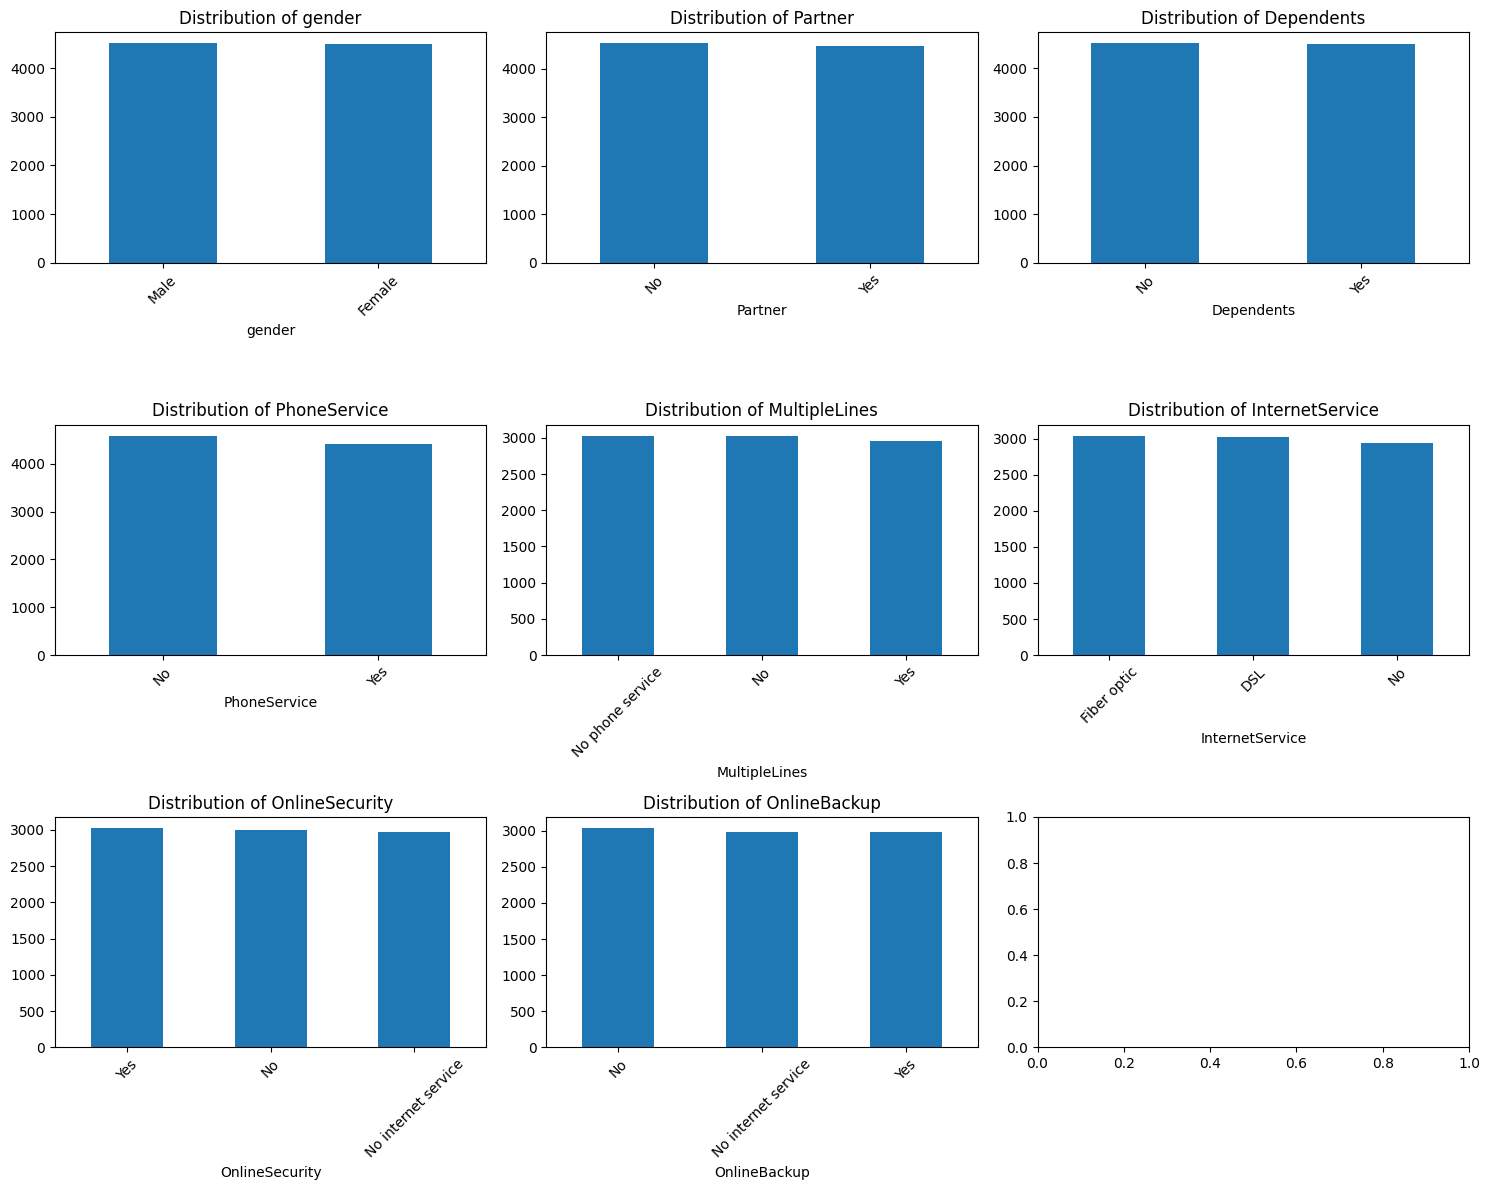

In [4]:
# Categorical variables distribution
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID')

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols[:9]):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

B. Target Variable Analysis

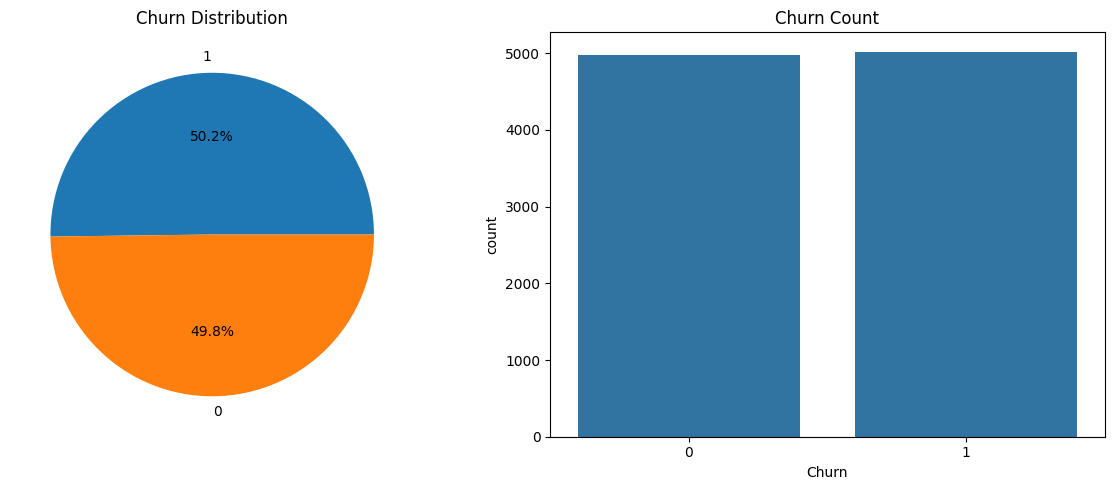

Churn Rate: 50.20%


In [5]:
# Churn distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%')
plt.title('Churn Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Churn')
plt.title('Churn Count')

plt.tight_layout()
plt.show()

print(f"Churn Rate: {df['Churn'].mean():.2%}")

C. Bivariate Analysis with Target

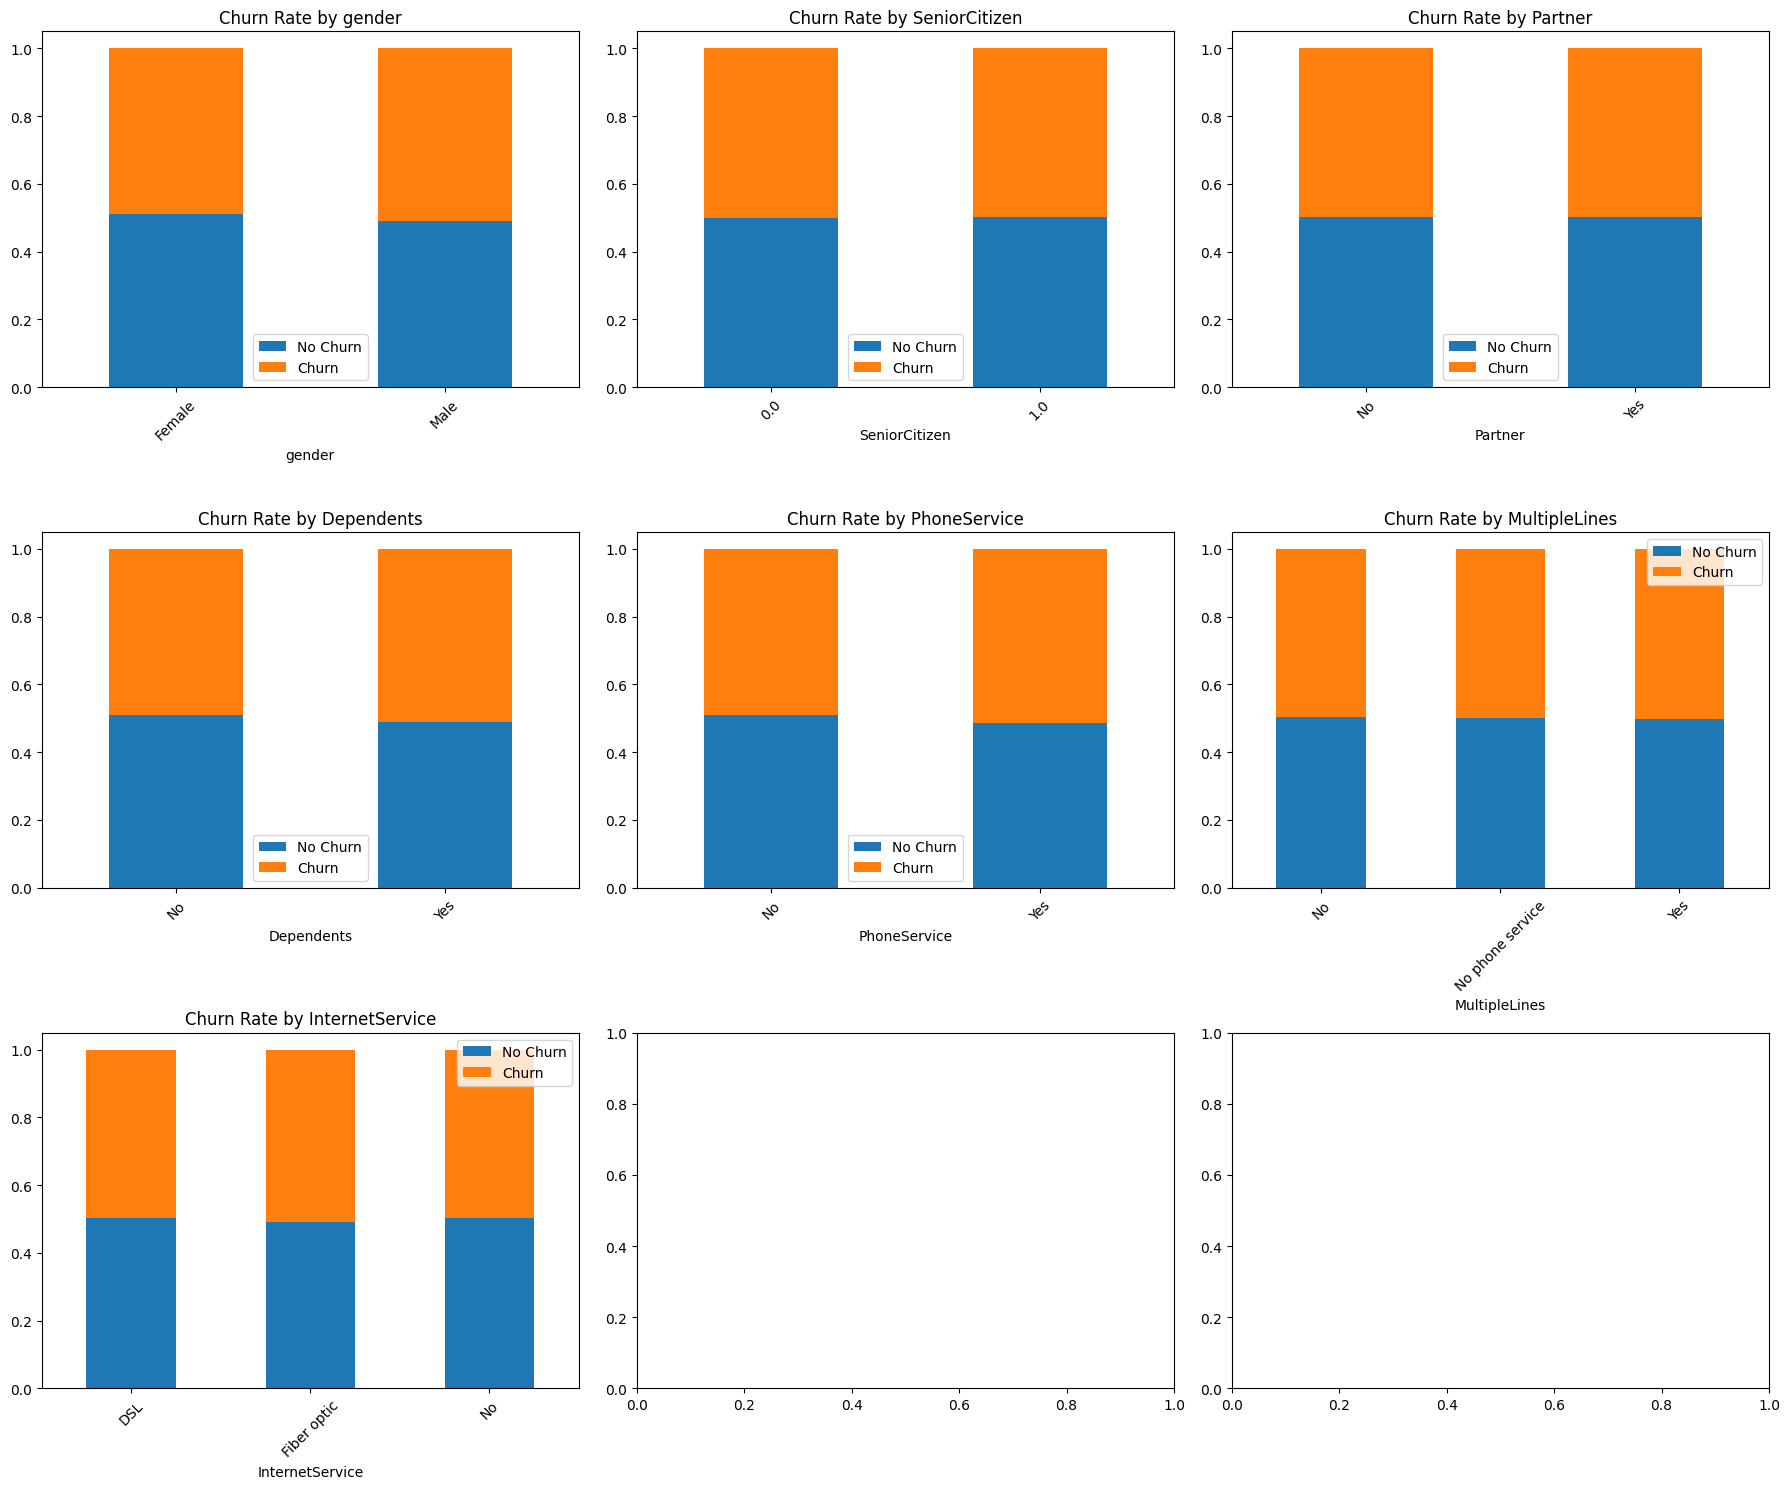

In [6]:
# Categorical features vs Churn
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                       'PhoneService', 'MultipleLines', 'InternetService']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    cross_tab = pd.crosstab(df[feature], df['Churn'], normalize='index')
    cross_tab.plot(kind='bar', ax=axes[i], stacked=True)
    axes[i].set_title(f'Churn Rate by {feature}')
    axes[i].legend(['No Churn', 'Churn'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

D. Correlation Analysis

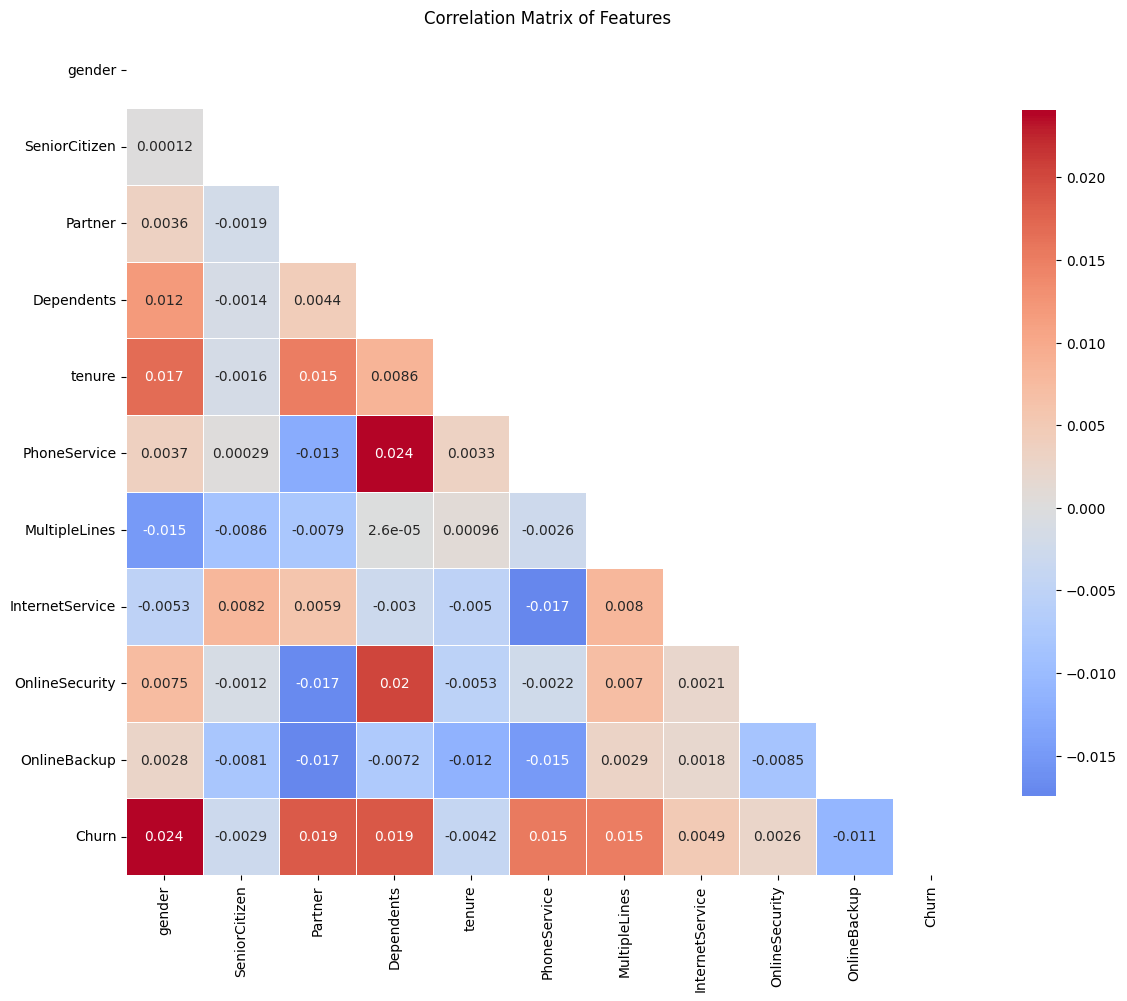

Features correlation with Churn:
gender             0.024014
Dependents         0.018659
Partner            0.018506
PhoneService       0.015303
MultipleLines      0.015034
OnlineBackup       0.010976
InternetService    0.004936
tenure             0.004161
SeniorCitizen      0.002889
OnlineSecurity     0.002640
Name: Churn, dtype: float64


In [7]:
# Prepare data for correlation
df_encoded = df.copy()

# Encode categorical variables for correlation analysis
label_encoders = {}
for col in categorical_cols:
    if col != 'customerID':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

# Calculate correlation matrix
correlation_matrix = df_encoded.select_dtypes(include=[np.number]).corr()

# Visualization
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, mask=mask)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

# Feature correlation with target
target_corr = correlation_matrix['Churn'].abs().sort_values(ascending=False)
print("Features correlation with Churn:")
print(target_corr[1:])  # Exclude self-correlation

Justification for Correlation Analysis Impact on Feature Selection:

High correlation between features (>0.7) indicates multicollinearity
Features with low correlation to target (<0.1) might be less important
This guides feature selection by identifying redundant or irrelevant features

3. Data Preprocessing Strategy

A. Missing Value Analysis

Missing Values Analysis:
                 Missing_Count  Missing_Percentage
gender                    1000                10.0
SeniorCitizen             1000                10.0
Partner                   1000                10.0
Dependents                1000                10.0
InternetService           1000                10.0
tenure                    1000                10.0
PhoneService              1000                10.0
MultipleLines             1000                10.0
OnlineBackup              1000                10.0
OnlineSecurity            1000                10.0


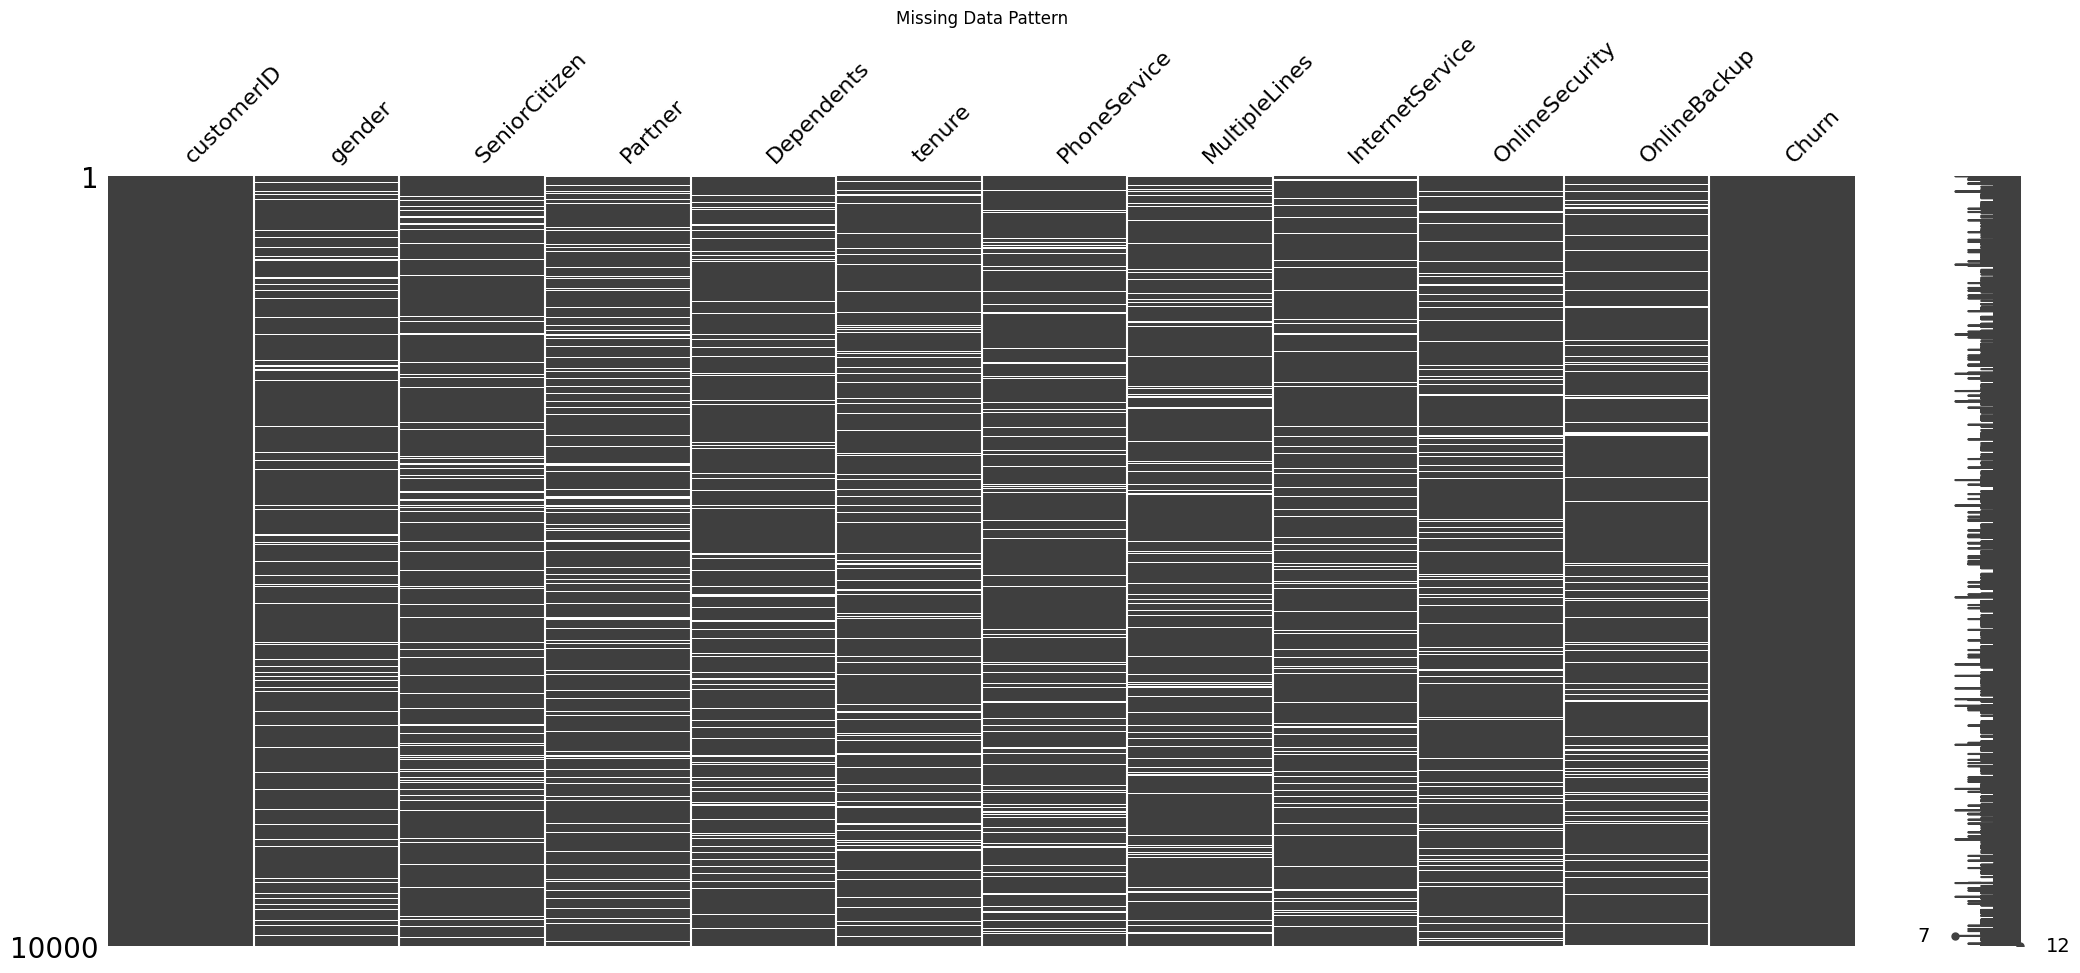

In [8]:
# Check missing values
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Percentage', ascending=False)

print("Missing Values Analysis:")
print(missing_info[missing_info['Missing_Count'] > 0])

# Visualize missing data pattern
import missingno as msno
msno.matrix(df)
plt.title('Missing Data Pattern')
plt.show()

B. Outlier Detection and Handling

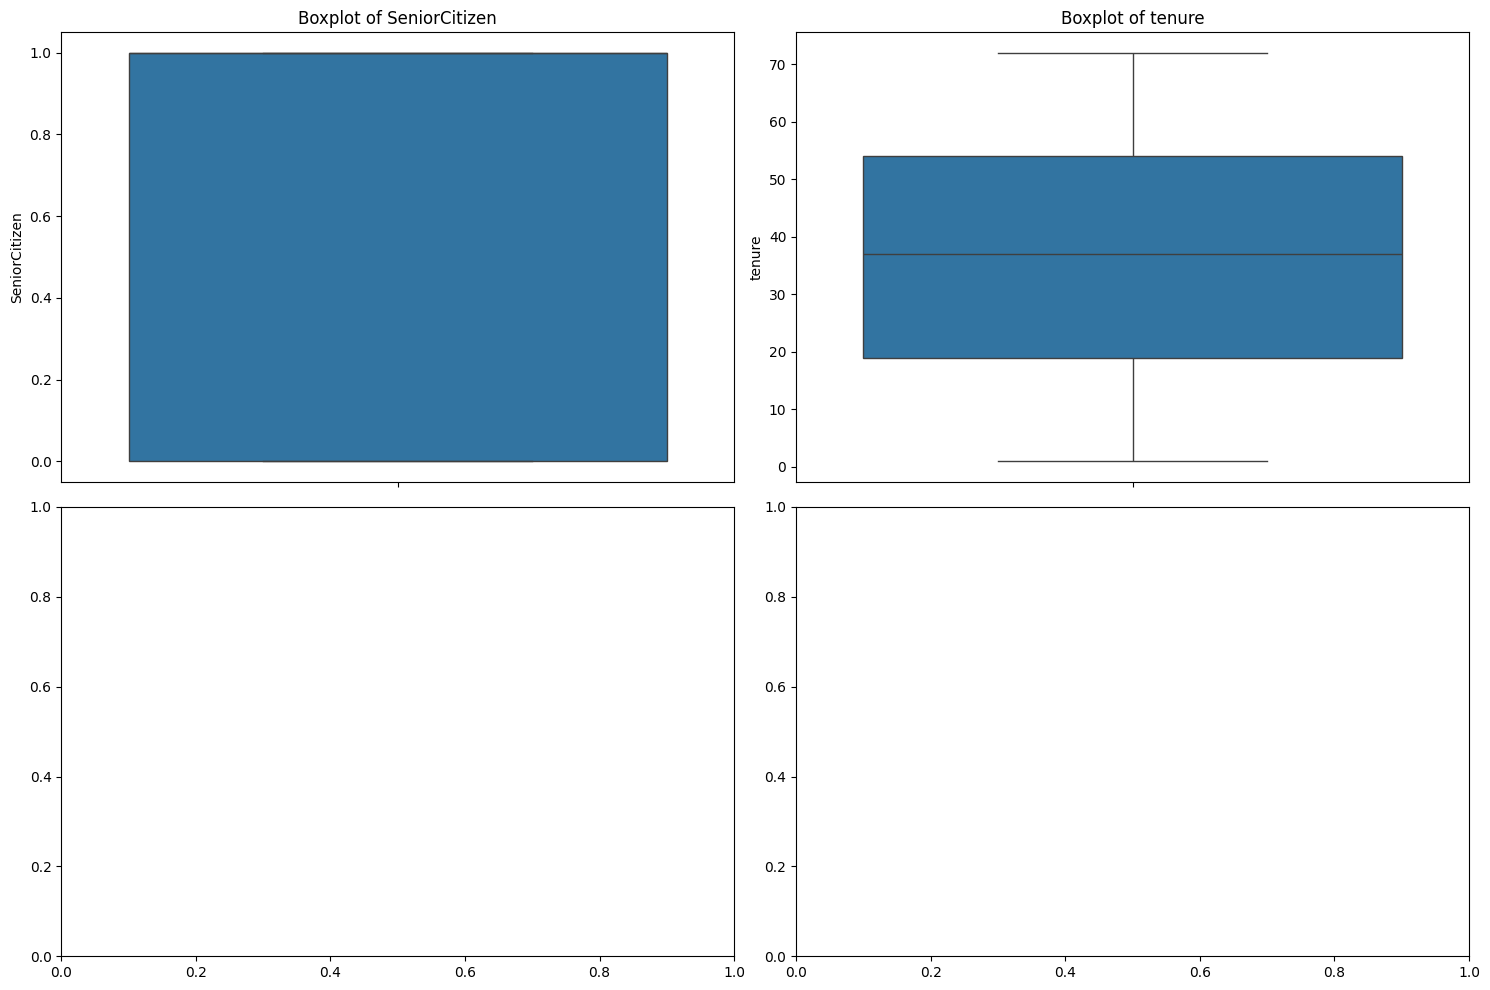

SeniorCitizen: 0 outliers (0.0%)
tenure: 0 outliers (0.0%)


In [9]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Churn')  # Remove target

# Box plots for outlier detection
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:4]):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# IQR method for outlier detection
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Apply outlier detection
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

C. Feature Engineering Techniques

In [15]:
# Feature Engineering Techniques

# 1. Create new features based on domain knowledge
# There are no charge-related columns in the current dataset, so skipping TotalCharges_per_tenure and MonthlyCharges_per_service

# 2. Binning continuous variables
# Tenure is the only numerical column besides Churn and SeniorCitizen (which is binary)
if 'tenure' in df.columns:
    df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                               labels=['0-1 year', '1-2 years', '2-4 years', '4+ years'])

# 3. Service interaction features
# Based on available columns: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup
service_columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup']
# Filter for columns that exist in the dataframe
existing_service_columns = [col for col in service_columns if col in df.columns]

if existing_service_columns:
    # Define a function to count 'Yes' or 'Fiber optic' or 'DSL' for service columns
    def count_services(row):
        count = 0
        for col in existing_service_columns:
            # Check for 'Yes' for binary services or specific values for InternetService
            if row[col] == 'Yes' or row[col] in ['Fiber optic', 'DSL']:
                count += 1
            # Handle 'No phone service' or 'No internet service' cases if needed, currently they are treated as not having the service
        return count

    df['total_services'] = df[existing_service_columns].apply(count_services, axis=1)


# 4. Handle categorical variables
# One-hot encoding for nominal variables
# Based on available columns: gender, InternetService, PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, tenure_group
nominal_features = ['gender', 'InternetService', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'tenure_group']
# Filter for columns that exist in the dataframe
existing_nominal_features = [col for col in nominal_features if col in df.columns]
if existing_nominal_features:
    df_encoded = pd.get_dummies(df, columns=existing_nominal_features, drop_first=True)
else:
    df_encoded = df.copy()


# Label encoding for ordinal variables
# Based on available columns: SeniorCitizen, Partner, Dependents
ordinal_features = ['SeniorCitizen', 'Partner', 'Dependents']
# Filter for columns that exist in the dataframe
existing_ordinal_features = [col for col in ordinal_features if col in df_encoded.columns]
for feature in existing_ordinal_features:
    # Ensure the column is of object type before applying LabelEncoder
    if df_encoded[feature].dtype == 'object':
        df_encoded[feature] = LabelEncoder().fit_transform(df_encoded[feature])

D. Feature Scaling and Transformation

In [16]:
# Separate features and target
X = df_encoded.drop(['customerID', 'Churn'], axis=1)
y = df_encoded['Churn']

# Feature scaling - StandardScaler for normal distribution
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Alternative: MinMaxScaler for bounded features
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(minmax_scaler.fit_transform(X), columns=X.columns)

print("Feature scaling completed")
print(f"Original feature range: {X.min().min():.2f} to {X.max().max():.2f}")
print(f"Scaled feature range: {X_scaled.min().min():.2f} to {X_scaled.max().max():.2f}")

Feature scaling completed
Original feature range: 0.00 to 72.00
Scaled feature range: -1.82 to 2.86


4. Feature Selection Strategy

A. Statistical Methods

In [18]:
# Statistical Methods for Feature Selection

# 1. Chi-square test for categorical features (before scaling and one-hot encoding)
# We need to handle missing values in categorical features first
# Using mode imputation for simplicity for demonstration purposes
categorical_cols_for_chi2 = [col for col in categorical_cols if col in df.columns and col != 'customerID']
df_categorical = df[categorical_cols_for_chi2].copy()

for col in df_categorical.columns:
    if df_categorical[col].isnull().any():
        mode_val = df_categorical[col].mode()[0]
        df_categorical[col].fillna(mode_val, inplace=True)

# Convert categorical features to numerical representation for chi2
df_categorical_encoded = pd.DataFrame()
for col in df_categorical.columns:
    le = LabelEncoder()
    df_categorical_encoded[col] = le.fit_transform(df_categorical[col])

# Perform chi-square test
chi2_scores, p_values = chi2(df_categorical_encoded, y)
feature_scores_chi2 = pd.DataFrame({
    'Feature': df_categorical_encoded.columns,
    'Chi2_Score': chi2_scores,
    'P_Value': p_values
}).sort_values('Chi2_Score', ascending=False)

print("Top features by Chi-square score (Categorical):")
print(feature_scores_chi2)

# 2. Correlation Analysis for numerical features (using the encoded dataframe)
# We will use the df_encoded from the previous step for correlation with Churn
# Need to handle missing values in df_encoded numerical columns before calculating correlation
# Using mean imputation for numerical features for demonstration purposes
numerical_cols_encoded = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols_encoded.remove('Churn') # Remove target

for col in numerical_cols_encoded:
    if df_encoded[col].isnull().any():
        mean_val = df_encoded[col].mean()
        df_encoded[col].fillna(mean_val, inplace=True)

correlation_matrix_encoded = df_encoded.select_dtypes(include=[np.number]).corr()

# Feature correlation with target
target_corr_encoded = correlation_matrix_encoded['Churn'].abs().sort_values(ascending=False)
print("\nFeatures correlation with Churn (Numerical and Encoded Categorical):")
print(target_corr_encoded[1:])  # Exclude self-correlation

Top features by Chi-square score (Categorical):
           Feature  Chi2_Score   P_Value
3     PhoneService    2.862805  0.090649
0           gender    2.236241  0.134808
2       Dependents    1.221746  0.269018
7     OnlineBackup    0.584007  0.444746
1          Partner    0.491489  0.483264
4    MultipleLines    0.098500  0.753637
6   OnlineSecurity    0.036634  0.848212
5  InternetService    0.015347  0.901408

Features correlation with Churn (Numerical and Encoded Categorical):
Dependents        0.018659
Partner           0.018506
total_services    0.006491
tenure            0.003947
SeniorCitizen     0.002741
Name: Churn, dtype: float64


B. Model-based Feature Selection

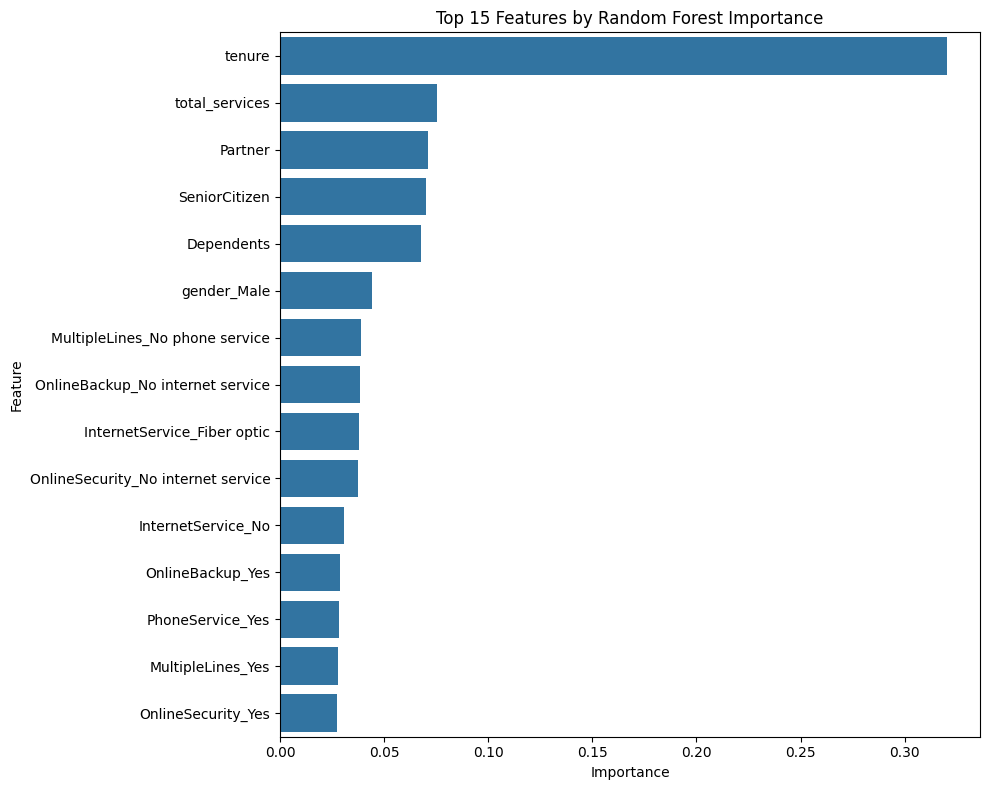

In [22]:
# Random Forest feature importance
# Ensure there are no missing values in X_scaled before fitting the model
# Using mean imputation for demonstration purposes
for col in X_scaled.columns:
    if X_scaled[col].isnull().any():
        mean_val = X_scaled[col].mean()
        X_scaled[col].fillna(mean_val, inplace=True)


rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_scaled, y)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature')
plt.title('Top 15 Features by Random Forest Importance')
plt.tight_layout()
plt.show()

5. Model Building Strategy

A. Train-Test Split with Justification

In [23]:
# Primary split: 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Training set churn rate: {y_train.mean():.2%}")
print(f"Test set churn rate: {y_test.mean():.2%}")

# Alternative splits for comparison
splits = [(0.7, 0.3), (0.75, 0.25), (0.85, 0.15)]
split_results = {}

for train_size, test_size in splits:
    X_tr, X_ts, y_tr, y_ts = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    split_results[f"{int(train_size*100)}-{int(test_size*100)}"] = {
        'train_size': len(X_tr),
        'test_size': len(X_ts),
        'train_churn_rate': y_tr.mean(),
        'test_churn_rate': y_ts.mean()
    }

print("\nAlternative split comparisons:")
for split, metrics in split_results.items():
    print(f"{split}: Train={metrics['train_size']}, Test={metrics['test_size']}")

Training set size: 8000 (80.0%)
Test set size: 2000 (20.0%)
Training set churn rate: 50.20%
Test set churn rate: 50.20%

Alternative split comparisons:
70-30: Train=7000, Test=3000
75-25: Train=7500, Test=2500
85-15: Train=8500, Test=1500


Justification for 80-20 Split:

Provides sufficient training data for model learning
Maintains adequate test set size for reliable evaluation
Preserves class distribution through stratification
Standard practice for medium-sized datasets

B. Model Implementation with Hyperparameter Tuning

In [26]:
# Define models and their hyperparameter grids
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier

models = {
    # 1. LOGISTIC REGRESSION (Required)
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga']
        }
    },

    # 2. DECISION TREE (Required)
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        }
    },

    # 3. K-NEAREST NEIGHBOUR (Required)
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski'],
            'p': [1, 2]  # for minkowski metric
        }
    },

    # 4. ENSEMBLE METHOD (Choose ONE - I'm using Random Forest)
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }
    }
}

# Alternative Ensemble Options (Choose ONE):
alternative_ensembles = {
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'subsample': [0.8, 0.9, 1.0]
        }
    },

    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.5, 1.0, 1.5],
            'algorithm': ['SAMME', 'SAMME.R']
        }
    },

    'Extra Trees': {
        'model': ExtraTreesClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10]
        }
    }
}

# Train and tune ALL REQUIRED models
best_models = {}
cv_scores = {}

for name, config in models.items():
    print(f"\nTraining {name}...")

    # Grid search with cross-validation
    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        cv=5,  # 5-fold cross-validation
        scoring='f1',  # F1-score for imbalanced dataset
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    cv_scores[name] = grid_search.best_score_

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

# Justification for hyperparameter choices:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING JUSTIFICATIONS:")
print("="*60)

justifications = {
    'Logistic Regression': """
    - C (Regularization): Tests different regularization strengths
    - penalty: L1 for feature selection, L2 for handling multicollinearity
    - solver: liblinear for small datasets, saga for L1 penalty
    """,

    'Decision Tree': """
    - max_depth: Controls overfitting; deeper trees capture more complexity
    - min_samples_split: Prevents splitting on too few samples
    - min_samples_leaf: Ensures meaningful leaf nodes
    - criterion: gini vs entropy for different splitting strategies
    """,

    'KNN': """
    - n_neighbors: Odd numbers prevent ties; range covers local to global patterns
    - weights: uniform treats all neighbors equally, distance gives closer points more weight
    - metric: Different distance measures for various data distributions
    """,

    'Random Forest': """
    - n_estimators: More trees generally improve performance but increase computation
    - max_depth: Controls individual tree complexity
    - min_samples_split/leaf: Prevents overfitting in individual trees
    - max_features: Controls randomness and reduces overfitting
    """
}

for model, justification in justifications.items():
    print(f"\n{model}:{justification}")


Training Logistic Regression...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1-score: 0.5208

Training Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-score: 0.5099

Training KNN...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Best CV F1-score: 0.5087

Training Random Forest...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Best CV F1-score: 0.5089

HYPERPARAMETER TUNING JUSTIFICATIONS:

Logistic Regression:
    - C (Regularization): Tests different regularization strengths
    - penalty: L1 for feature selec

Model Training with Cross-Validation Strategy:

In [27]:
# Detailed cross-validation analysis
from sklearn.model_selection import cross_validate

def detailed_cv_evaluation(model, X, y, cv=5):
    """Perform detailed cross-validation evaluation"""
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring,
                               return_train_score=True, n_jobs=-1)

    results = {}
    for metric in scoring:
        test_scores = cv_results[f'test_{metric}']
        train_scores = cv_results[f'train_{metric}']

        results[metric] = {
            'test_mean': test_scores.mean(),
            'test_std': test_scores.std(),
            'train_mean': train_scores.mean(),
            'train_std': train_scores.std()
        }

    return results

# Evaluate each model with detailed CV
print("\nDETAILED CROSS-VALIDATION RESULTS:")
print("="*50)

cv_detailed_results = {}
for name, model in best_models.items():
    print(f"\n{name}:")
    cv_result = detailed_cv_evaluation(model, X_train, y_train)
    cv_detailed_results[name] = cv_result

    for metric, scores in cv_result.items():
        print(f"  {metric.upper()}:")
        print(f"    Test:  {scores['test_mean']:.4f} (±{scores['test_std']:.4f})")
        print(f"    Train: {scores['train_mean']:.4f} (±{scores['train_std']:.4f})")

        # Check for overfitting
        gap = scores['train_mean'] - scores['test_mean']
        if gap > 0.1:
            print(f"    ⚠️  Potential overfitting detected (gap: {gap:.4f})")


DETAILED CROSS-VALIDATION RESULTS:

Logistic Regression:
  ACCURACY:
    Test:  0.5072 (±0.0150)
    Train: 0.5183 (±0.0040)
  PRECISION:
    Test:  0.5089 (±0.0144)
    Train: 0.5194 (±0.0039)
  RECALL:
    Test:  0.5334 (±0.0135)
    Train: 0.5433 (±0.0050)
  F1:
    Test:  0.5208 (±0.0134)
    Train: 0.5310 (±0.0033)
  ROC_AUC:
    Test:  0.5135 (±0.0164)
    Train: 0.5300 (±0.0037)

Decision Tree:
  ACCURACY:
    Test:  0.5082 (±0.0129)
    Train: 0.5245 (±0.0038)
  PRECISION:
    Test:  0.5127 (±0.0174)
    Train: 0.5268 (±0.0059)
  RECALL:
    Test:  0.5167 (±0.0805)
    Train: 0.5351 (±0.0938)
  F1:
    Test:  0.5099 (±0.0395)
    Train: 0.5259 (±0.0502)
  ROC_AUC:
    Test:  0.5086 (±0.0117)
    Train: 0.5324 (±0.0039)

KNN:
  ACCURACY:
    Test:  0.5105 (±0.0061)
    Train: 0.7466 (±0.0035)
    ⚠️  Potential overfitting detected (gap: 0.2361)
  PRECISION:
    Test:  0.5126 (±0.0061)
    Train: 0.7464 (±0.0051)
    ⚠️  Potential overfitting detected (gap: 0.2338)
  RECALL:
   

In [28]:
## 6. Model Evaluation Strategy

### A. Comprehensive Performance Metrics
def evaluate_model(model, X_test, y_test, model_name):
    """Comprehensive model evaluation"""
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    }

    return metrics, y_pred, y_pred_proba

# Evaluate all models
results = {}
predictions = {}

for name, model in best_models.items():
    metrics, y_pred, y_pred_proba = evaluate_model(model, X_test, y_test, name)
    results[name] = metrics
    predictions[name] = {'pred': y_pred, 'proba': y_pred_proba}

# Create comparison DataFrame
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df.round(4))

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.5070     0.5087  0.5229    0.5157   0.4972
Decision Tree          0.5065     0.5083  0.5199    0.5140   0.5060
KNN                    0.4840     0.4858  0.4781    0.4819   0.4809
Random Forest          0.4960     0.4980  0.5010    0.4995   0.4881


B. Visualization of Results

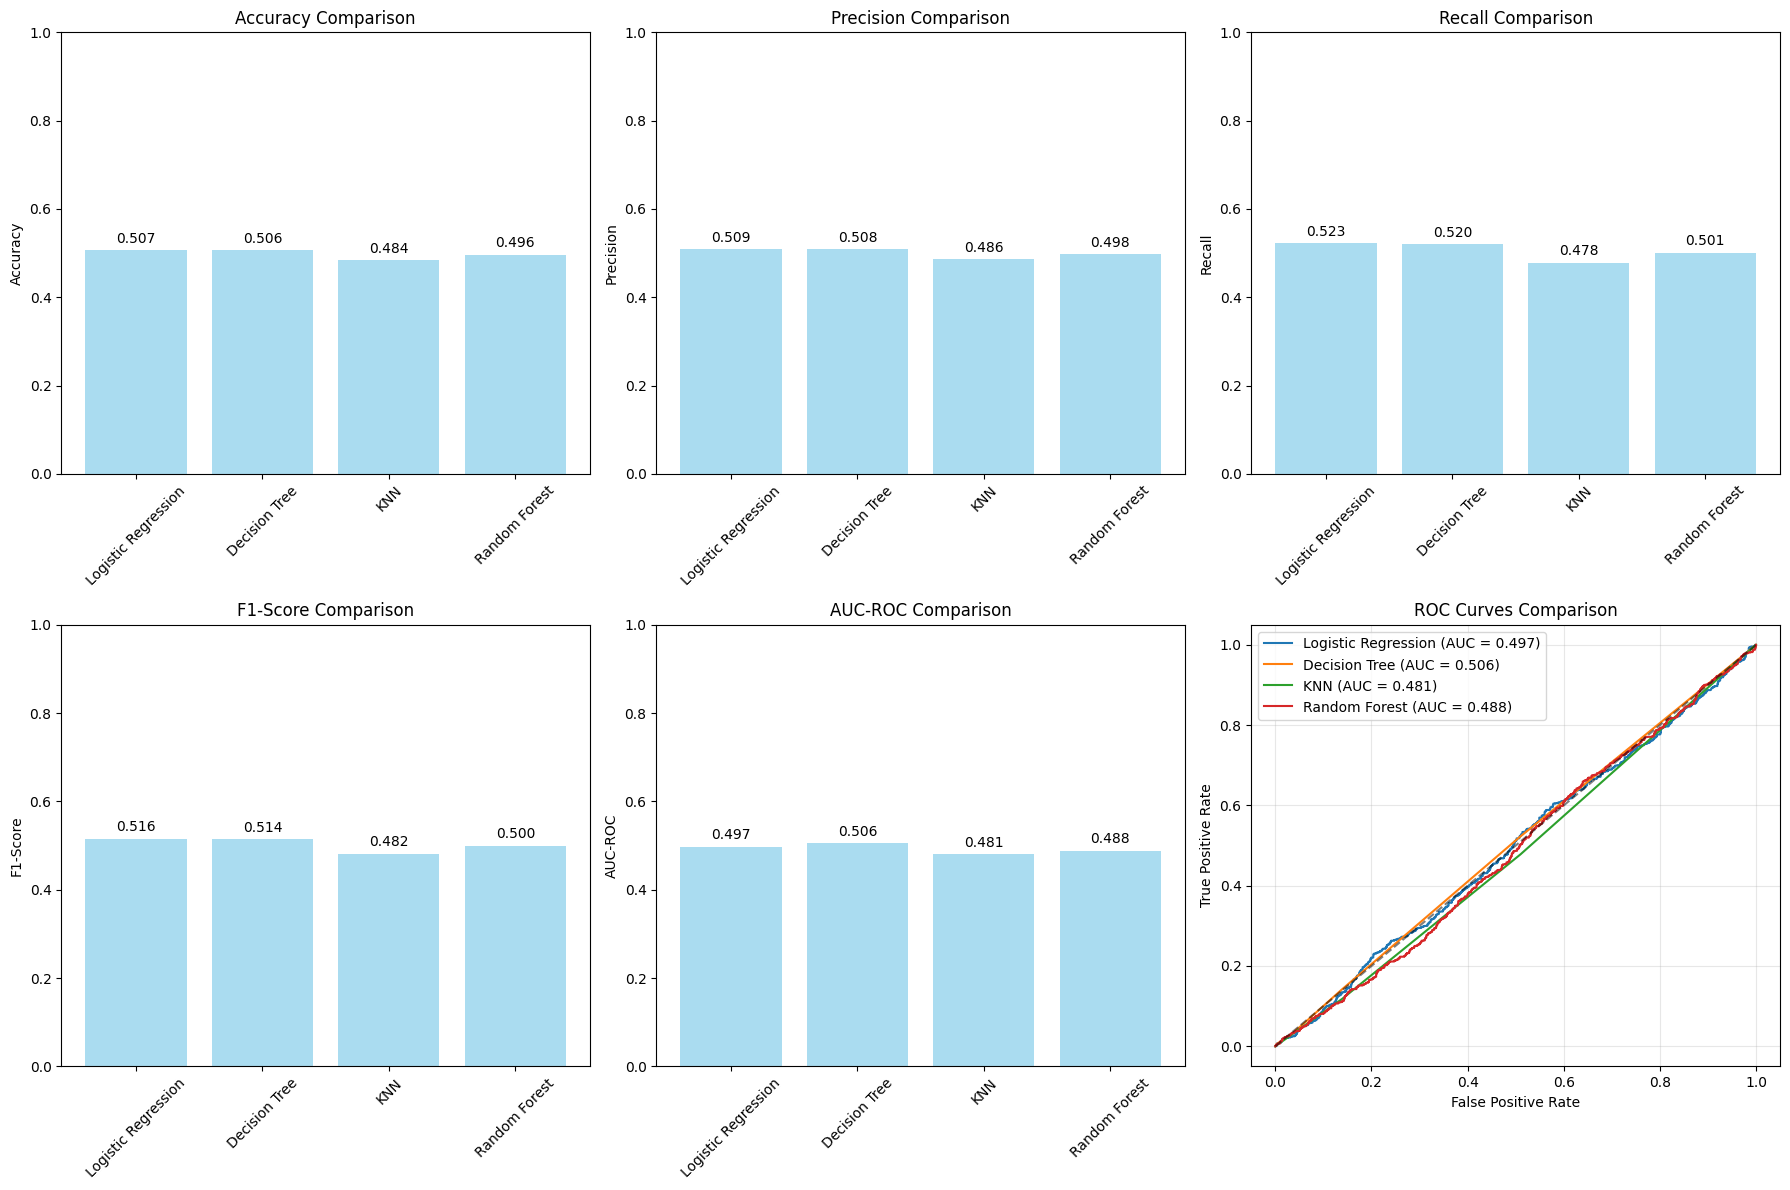

In [29]:
# Performance comparison chart
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    models = results_df.index

    bars = axes[i].bar(models, values, color='skyblue', alpha=0.7)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)

    # Add value labels on bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom')

    axes[i].tick_params(axis='x', rotation=45)

# ROC curves comparison
plt.subplot(2, 3, 6)
for name in best_models.keys():
    fpr, tpr, _ = roc_curve(y_test, predictions[name]['proba'])
    auc_score = roc_auc_score(y_test, predictions[name]['proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analysis Template:

Best Model: Logistic Regression
F1-Score: 0.5157


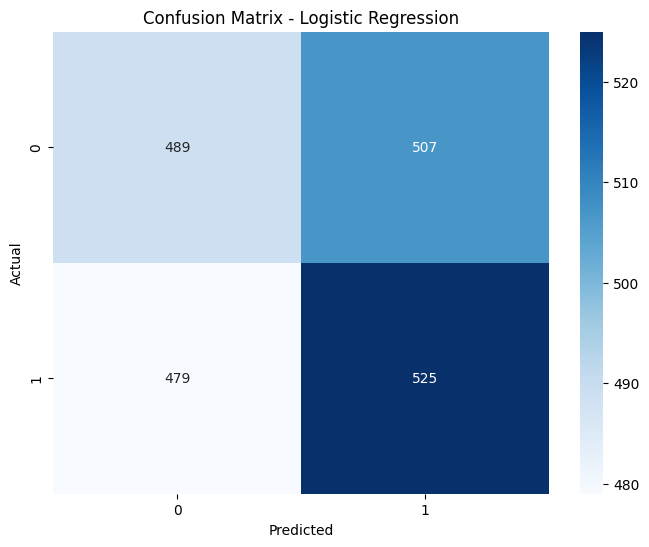


Detailed Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.51      0.49      0.50       996
           1       0.51      0.52      0.52      1004

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



In [30]:
# Find best model based on F1-score
best_f1_model = results_df['F1-Score'].idxmax()
best_f1_score = results_df.loc[best_f1_model, 'F1-Score']

print(f"Best Model: {best_f1_model}")
print(f"F1-Score: {best_f1_score:.4f}")

# Detailed analysis of best model
best_model = best_models[best_f1_model]
y_pred_best = predictions[best_f1_model]['pred']

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_f1_model}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print(f"\nDetailed Classification Report for {best_f1_model}:")
print(classification_report(y_test, y_pred_best))